In [1]:
!pip uninstall -y transformers -q
!pip install transformers==4.38.2 -q
!pip install tensorflow -q

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

print("TensorFlow Version :", tf.__version__)
print("GPU Available      :", len(tf.config.list_physical_devices('GPU')))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 130.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 130.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
TensorFlow Version : 2.20.0
GPU Available      : 1


# Load Dataset

In [14]:
df = pd.read_csv("mental_health.csv")

df = df[['statement', 'status']]
df = df.dropna().reset_index(drop=True)

print("Dataset Shape:", df.shape)
print(df['status'].value_counts())

Dataset Shape: (52681, 2)
status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


# Text Cleaning

In [15]:
def clean_text_bert(text):
    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "@USER", text)

    text = text.replace("\n", " ")
    text = text.replace("\r", " ")

    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r"\s+", " ", text).strip()

    return text

df['processed_text'] = df['statement'].apply(clean_text_bert)

df = df[df['processed_text'].str.split().str.len() > 3]
df = df.reset_index(drop=True)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (50821, 3)


# Label Encoding

In [16]:
label_map = {label: idx for idx, label in enumerate(df['status'].unique())}
reverse_label_map = {idx: label for label, idx in label_map.items()}

num_classes = len(label_map)

df['label'] = df['status'].map(label_map)

print("Label Mapping:")
print(label_map)

Label Mapping:
{'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}


# Train Valid Test Split

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train Size :", len(X_train))
print("Valid Size :", len(X_valid))
print("Test Size  :", len(X_test))

Train Size : 40656
Valid Size : 5082
Test Size  : 5083


# Hugging Face

In [18]:
from huggingface_hub import login

login(token="________")

# Tokenization Mental Bert

In [19]:
MODEL_NAME = "mental/mental-bert-base-uncased"

MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_data(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='tf'
    )

train_encodings = encode_data(X_train)
valid_encodings = encode_data(X_valid)
test_encodings  = encode_data(X_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


# TF Dataset

In [20]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': train_encodings['input_ids'],
        'attention_mask': train_encodings['attention_mask']
    },
    y_train.values
)).shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

valid_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': valid_encodings['input_ids'],
        'attention_mask': valid_encodings['attention_mask']
    },
    y_valid.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': test_encodings['input_ids'],
        'attention_mask': test_encodings['attention_mask']
    },
    y_test.values
)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Build Model MentalBERT

In [21]:
model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    from_pt=True
)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)

loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=['accuracy']
)

model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertForSequenceClassification: ['bert.embeddings.position_ids']
- This IS expected if you are initializing TFBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['bert.pooler.dense.weight', 'bert.pooler.dense.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: "tf_bert_for_sequence_classification_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_113 (Dropout)       multiple                  0         
                                                                 
 classifier (Dense)          multiple                  5383      
                                                                 
Total params: 109487623 (417.66 MB)
Trainable params: 109487623 (417.66 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/5
5082/5082 [==============================] - 2545s 492ms/step - loss: 0.5423 - accuracy: 0.7895 - val_loss: 0.4115 - val_accuracy: 0.8323 - lr: 1.0000e-05
Epoch 2/5
5082/5082 [==============================] - ETA: 0s - loss: 0.3459 - accuracy: 0.8592
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
5082/5082 [==============================] - 2492s 490ms/step - loss: 0.3459 - accuracy: 0.8592 - val_loss: 0.4116 - val_accuracy: 0.8308 - lr: 1.0000e-05
Epoch 3/5
5082/5082 [==============================] - ETA: 0s - loss: 0.2264 - accuracy: 0.9101
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
5082/5082 [==============================] - 2493s 491ms/step - loss: 0.2264 - accuracy: 0.9101 - val_loss: 0.4368 - val_accuracy: 0.8377 - lr: 5.0000e-06


# Evaluation

In [23]:
predictions = model.predict(test_dataset)

y_pred_probs = tf.nn.softmax(predictions.logits, axis=-1).numpy()
y_pred = np.argmax(y_pred_probs, axis=1)

y_test_array = y_test.values

weighted_f1 = f1_score(y_test_array, y_pred, average='weighted')
macro_f1 = f1_score(y_test_array, y_pred, average='macro')

print(f"Weighted F1 Score : {weighted_f1:.4f}")
print(f"Macro F1 Score    : {macro_f1:.4f}")

print("\nClassification Report (MentalBERT Only):\n")
print(classification_report(
    y_test_array,
    y_pred,
    target_names=label_map.keys()
))

636/636 [==============================] - 110s 168ms/step
Weighted F1 Score : 0.8246
Macro F1 Score    : 0.8072

Classification Report (MentalBERT Only):

                      precision    recall  f1-score   support

             Anxiety       0.88      0.87      0.87       380
              Normal       0.94      0.95      0.95      1461
          Depression       0.79      0.78      0.78      1535
            Suicidal       0.74      0.71      0.72      1064
              Stress       0.70      0.79      0.74       258
             Bipolar       0.80      0.90      0.85       278
Personality disorder       0.84      0.66      0.74       107

            accuracy                           0.83      5083
           macro avg       0.81      0.81      0.81      5083
        weighted avg       0.83      0.83      0.82      5083



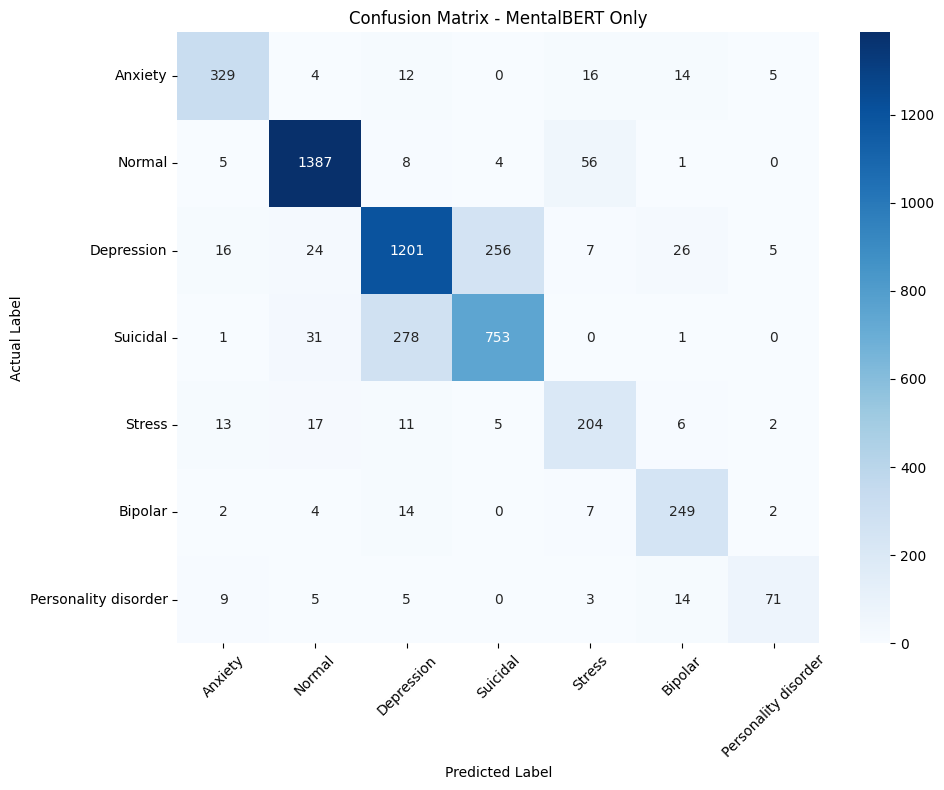

In [24]:
cm = confusion_matrix(y_test_array, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_map.keys(),
    yticklabels=label_map.keys()
)

plt.title("Confusion Matrix - MentalBERT Only")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Training History

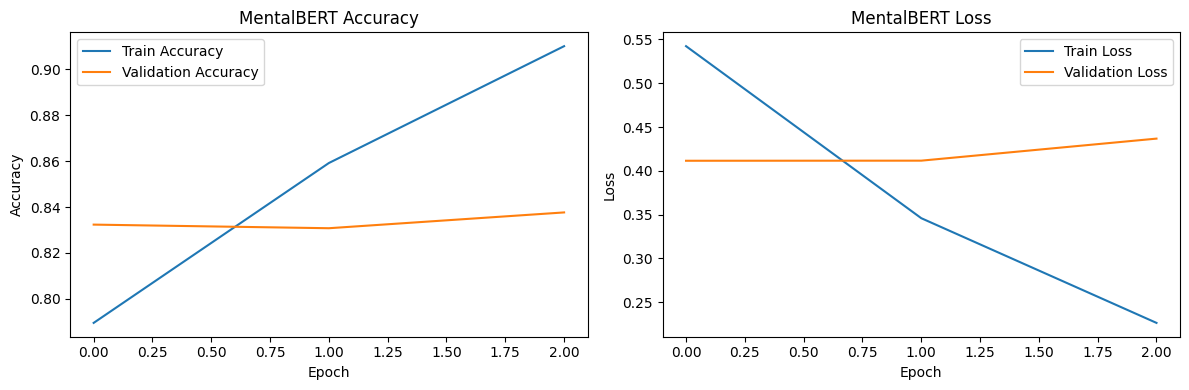

In [25]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("MentalBERT Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("MentalBERT Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Prediction Function

In [26]:
def predict_mental_health(text):
    cleaned_text = clean_text_bert(text)

    encoded_input = tokenizer(
        cleaned_text,
        return_tensors='tf',
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

    outputs = model(encoded_input)
    probs = tf.nn.softmax(outputs.logits, axis=-1).numpy()[0]

    pred_class = np.argmax(probs)
    confidence = probs[pred_class]

    print("=" * 50)
    print("Input Text       :", text)
    print("Predicted Label  :", reverse_label_map[pred_class])
    print(f"Confidence Score : {confidence:.4f}")
    print("=" * 50)

In [27]:
predict_mental_health("I feel hopeless and empty. I don't want to live anymore.")
predict_mental_health("I am very happy today and excited to meet my friends.")
predict_mental_health("My heart is racing and I am terrified to go outside.")

Input Text       : I feel hopeless and empty. I don't want to live anymore.
Predicted Label  : Depression
Confidence Score : 0.7814
Input Text       : I am very happy today and excited to meet my friends.
Predicted Label  : Normal
Confidence Score : 0.9799
Input Text       : My heart is racing and I am terrified to go outside.
Predicted Label  : Normal
Confidence Score : 0.5392


# Save Model

In [28]:
import os
import shutil
from google.colab import files

SAVE_PATH = "./mentalbert_only"

os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model & Tokenizer Saved!")

shutil.make_archive(
    "mentalbert_only",
    'zip',
    SAVE_PATH
)

print("ZIP File Created!")

files.download("mentalbert_only.zip")

Model & Tokenizer Saved!
ZIP File Created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>